In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Feature Data Shape:", X.shape)
print("Target Data Shape:", y.shape)

Feature Data Shape: (1797, 64)
Target Data Shape: (1797,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 1347
Testing Samples: 450


In [4]:
ocr_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

ocr_model.fit(X_train, y_train)

MLPClassifier(max_iter=1000, random_state=42)

In [5]:
y_pred = ocr_model.predict(X_test)

print("OCR Engine Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

OCR Engine Accuracy: 0.9711111111111111

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.95      1.00      0.97        37
           2       0.95      1.00      0.97        38
           3       0.98      0.96      0.97        46
           4       0.98      0.98      0.98        55
           5       0.98      0.95      0.97        59
           6       0.98      0.98      0.98        45
           7       1.00      0.98      0.99        41
           8       0.97      0.92      0.95        38
           9       0.94      1.00      0.97        48

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


Confusion Matrix:
[[41  0  1  0  1  0  0  0  0  0]
 [ 0 37  0  0  0  0  0  0  0  0]
 [ 0  0 38  0  0  0  0  0  0  0]
 [ 0  0  0 44  0  1  0  0  1  0]
 [ 0  1  0  0 54  0  0  0 

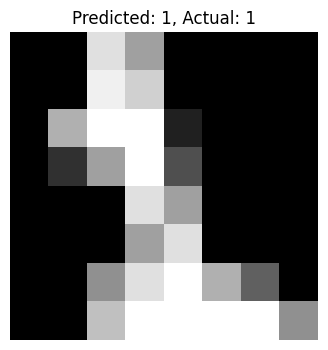

In [6]:
index = 5

plt.figure(figsize=(4,4))
plt.imshow(X_test[index].reshape(8, 8), cmap="gray")
plt.title(f"Predicted: {y_pred[index]}, Actual: {y_test[index]}")
plt.axis("off")
plt.show()

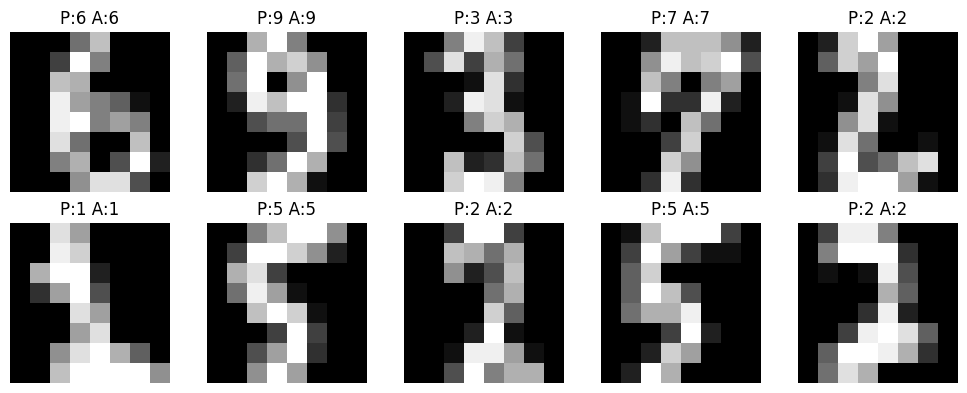

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray")
    ax.set_title(f"P:{y_pred[i]} A:{y_test[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()